Selected generations: [np.int64(1), np.int64(34), np.int64(67), np.int64(100)]


/tmp/ipykernel_6851/834315887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


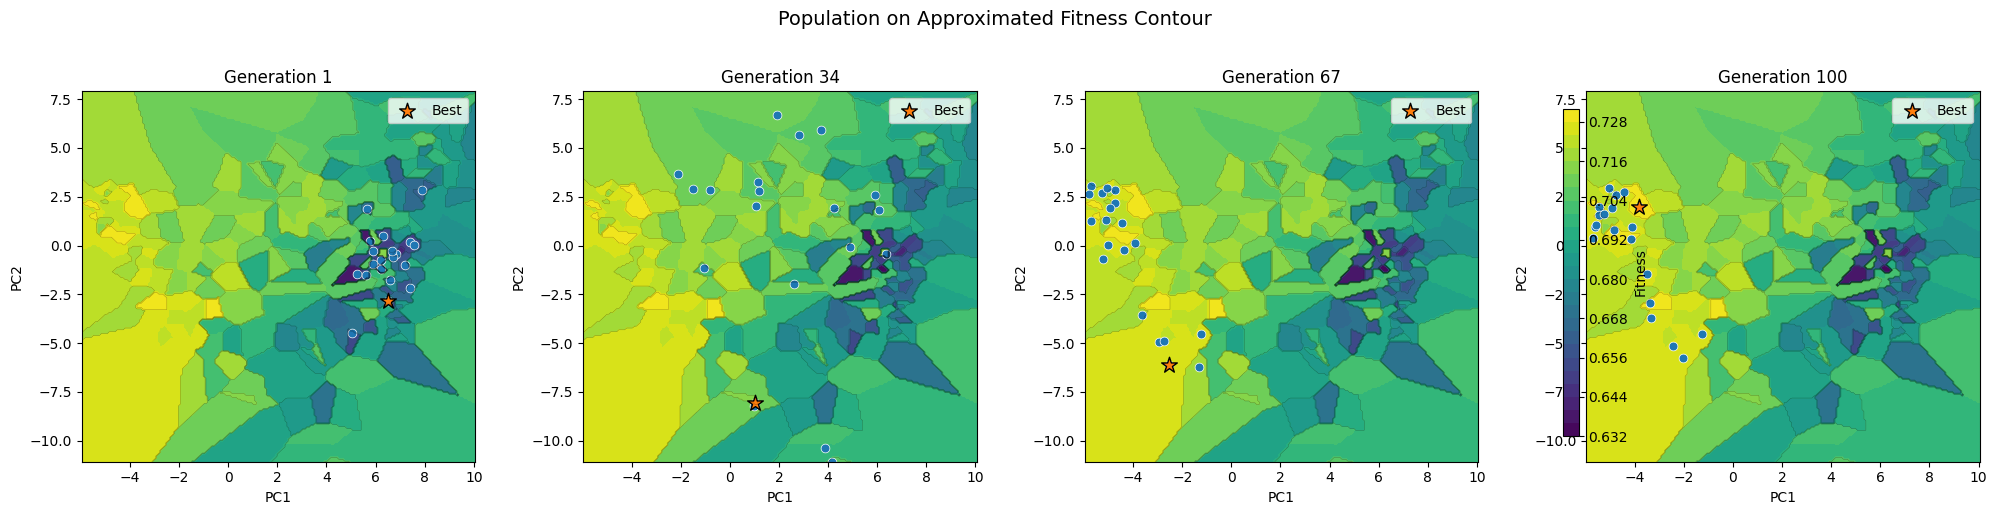

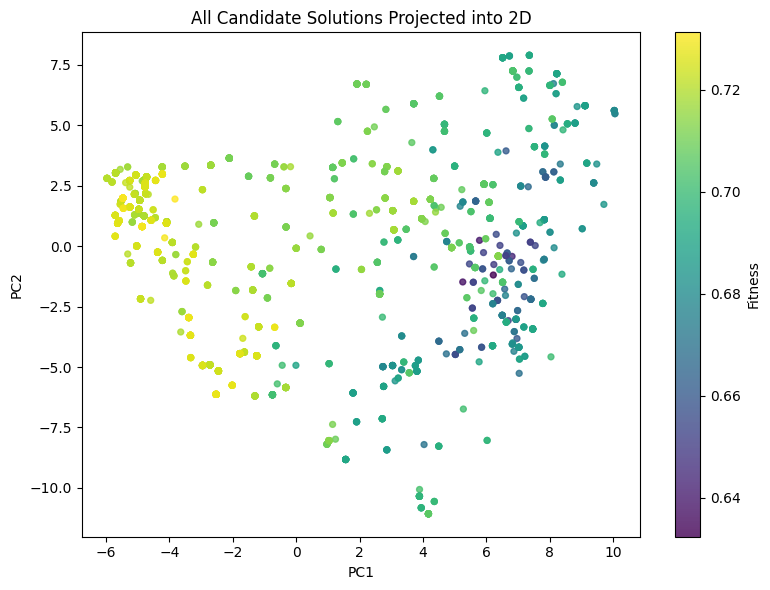

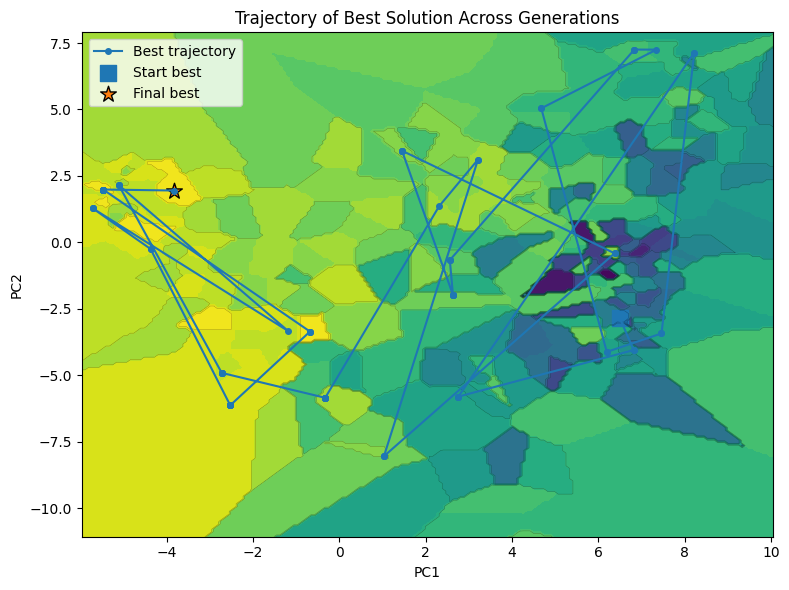

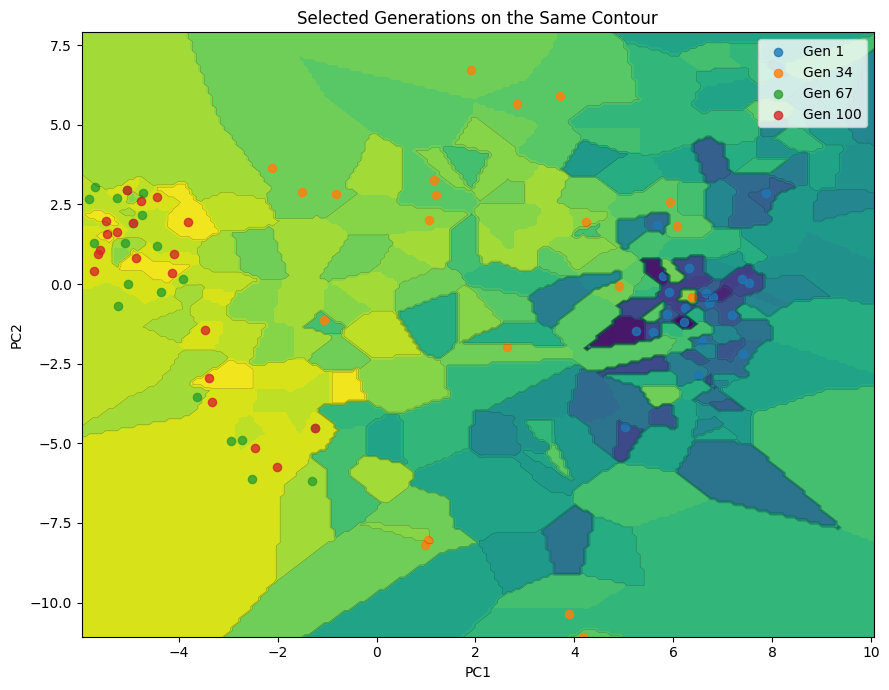

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.interpolate import griddata


# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
csv_path = "/content/population_state_history.csv"
df = pd.read_csv(csv_path)

# Chuyển cột mask từ string -> list
df["mask"] = df["mask"].apply(ast.literal_eval)

# Dùng mask để trực quan hóa đúng bản chất feature selection
X_mask = np.array(df["mask"].tolist(), dtype=float)

fitness = df["fitness"].values
generations = df["generation"].values
individuals = df["individual"].values


# =========================
# 2. GIẢM CHIỀU XUỐNG 2D BẰNG PCA
# =========================
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_mask)

df["u"] = coords_2d[:, 0]
df["v"] = coords_2d[:, 1]


# =========================
# 3. TẠO CONTOUR XẤP XỈ FITNESS LANDSCAPE
# =========================
u = df["u"].values
v = df["v"].values
f = df["fitness"].values

# Tạo grid 2D
grid_u, grid_v = np.meshgrid(
    np.linspace(u.min(), u.max(), 200),
    np.linspace(v.min(), v.max(), 200)
)

# Nội suy fitness lên grid
grid_f = griddata(
    points=(u, v),
    values=f,
    xi=(grid_u, grid_v),
    method="nearest"
)

# Nếu cubic bị NaN nhiều ở rìa, vá bằng nearest
if np.isnan(grid_f).any():
    grid_f_nearest = griddata(
        points=(u, v),
        values=f,
        xi=(grid_u, grid_v),
        method="nearest"
    )
    nan_mask = np.isnan(grid_f)
    grid_f[nan_mask] = grid_f_nearest[nan_mask]


# =========================
# 4. CHỌN CÁC GENERATION TIÊU BIỂU ĐỂ VẼ
# =========================
all_gens = sorted(df["generation"].unique())

# Chọn 4 mốc: đầu, 1/3, 2/3, cuối
if len(all_gens) >= 4:
    selected_gens = [
        all_gens[0],
        all_gens[len(all_gens) // 3],
        all_gens[(2 * len(all_gens)) // 3],
        all_gens[-1]
    ]
    selected_gens = sorted(list(set(selected_gens)))
else:
    selected_gens = all_gens

print("Selected generations:", selected_gens)


# =========================
# 5. VẼ CONTOUR + QUẦN THỂ TỪNG GENERATION
# =========================
n_plots = len(selected_gens)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), squeeze=False)
axes = axes[0]

for ax, gen in zip(axes, selected_gens):
    sub = df[df["generation"] == gen].copy()

    # contour nền
    contour = ax.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
    ax.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

    # scatter quần thể
    ax.scatter(sub["u"], sub["v"], s=40, edgecolors="white", linewidths=0.5)

    # đánh dấu cá thể tốt nhất của generation
    best_idx = sub["fitness"].idxmax()
    best_row = df.loc[best_idx]
    ax.scatter(
        best_row["u"], best_row["v"],
        s=140, marker="*", edgecolors="black", linewidths=1.0,
        label="Best"
    )

    ax.set_title(f"Generation {gen}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

fig.colorbar(contour, ax=axes, shrink=0.85, label="Fitness")
plt.suptitle("Population on Approximated Fitness Contour", y=1.02, fontsize=14)
plt.tight_layout()

plt.savefig("population_contour_selected_generations.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 6. VẼ TOÀN BỘ ĐIỂM THEO FITNESS
# =========================
plt.figure(figsize=(8, 6))
sc = plt.scatter(df["u"], df["v"], c=df["fitness"], s=18, alpha=0.8)
plt.colorbar(sc, label="Fitness")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("All Candidate Solutions Projected into 2D")
plt.tight_layout()
plt.savefig("all_population_projected_2d.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 7. VẼ TRAJECTORY CỦA BEST SOLUTION QUA CÁC GENERATION
# =========================
best_per_gen = df.loc[df.groupby("generation")["fitness"].idxmax()].sort_values("generation")

plt.figure(figsize=(8, 6))
plt.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

plt.plot(
    best_per_gen["u"], best_per_gen["v"],
    marker="o", linewidth=1.5, markersize=4,
    label="Best trajectory"
)

# đánh dấu điểm đầu và cuối
first_row = best_per_gen.iloc[0]
last_row = best_per_gen.iloc[-1]

plt.scatter(first_row["u"], first_row["v"], s=120, marker="s", label="Start best")
plt.scatter(last_row["u"], last_row["v"], s=140, marker="*", edgecolors="black", linewidths=1.0, label="Final best")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of Best Solution Across Generations")
plt.legend()
plt.tight_layout()
plt.savefig("best_solution_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 8. TÙY CHỌN: VẼ TẤT CẢ GENERATION TRONG 1 HÌNH
# =========================
plt.figure(figsize=(9, 7))
plt.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

for gen in selected_gens:
    sub = df[df["generation"] == gen]
    plt.scatter(sub["u"], sub["v"], s=35, alpha=0.8, label=f"Gen {gen}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Selected Generations on the Same Contour")
plt.legend()
plt.tight_layout()
plt.savefig("selected_generations_same_contour.png", dpi=300, bbox_inches="tight")
plt.show()

Selected generations: [np.int64(1), np.int64(34), np.int64(67), np.int64(100)]


/tmp/ipykernel_6851/834315887.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


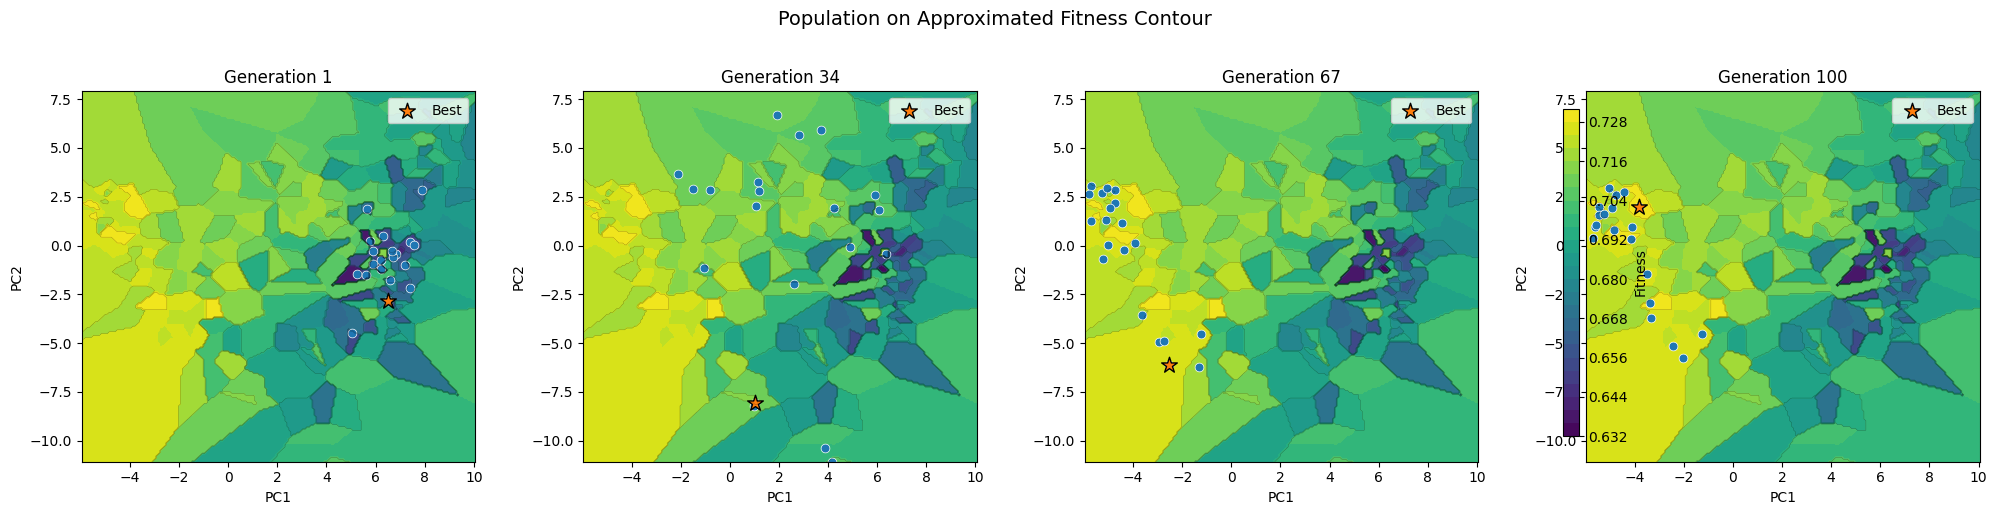

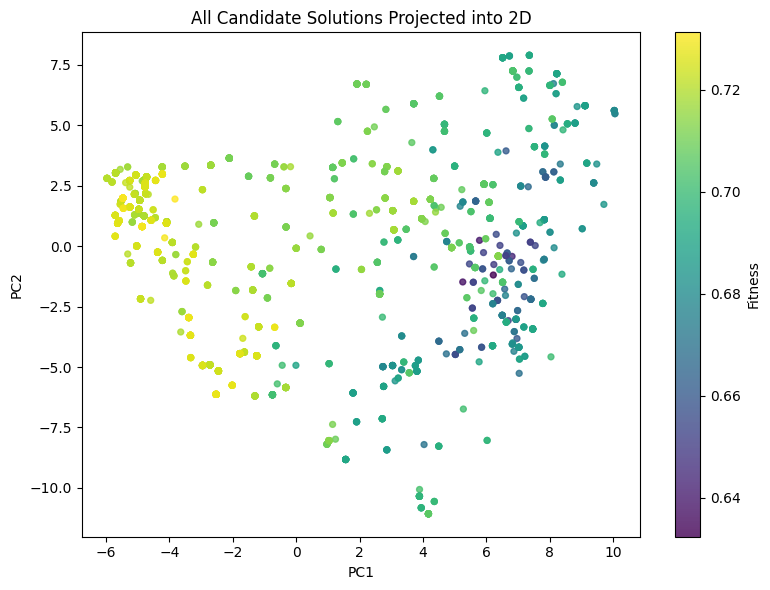

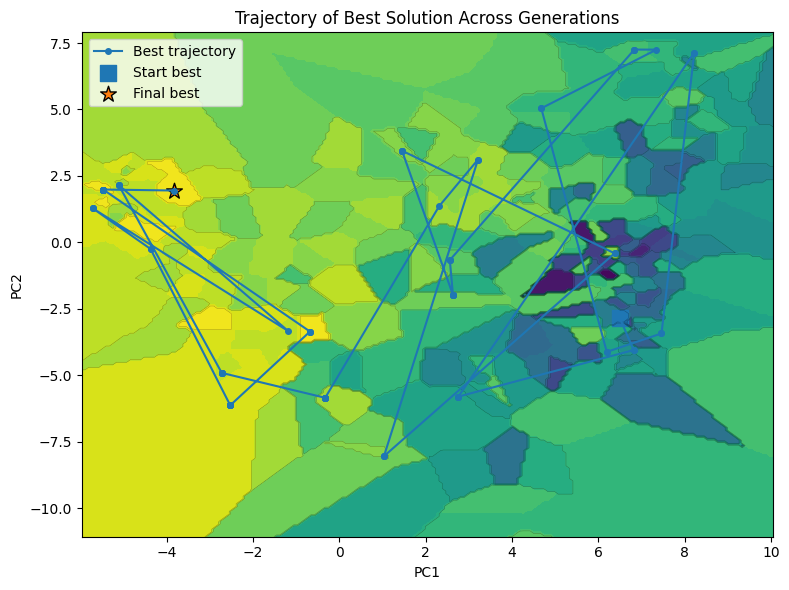

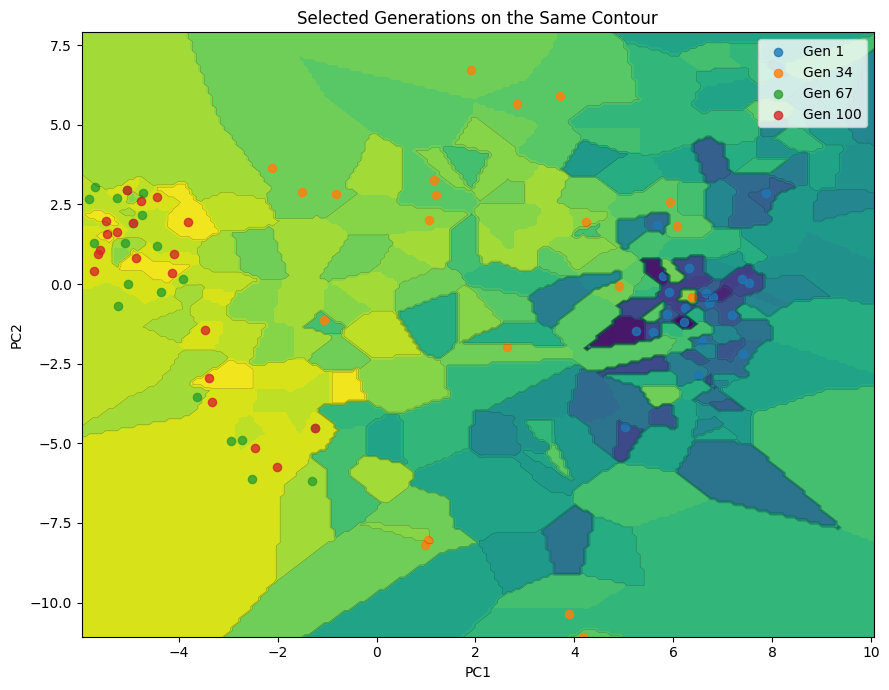

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.interpolate import griddata


# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
csv_path = "/content/population_state_history.csv"
df = pd.read_csv(csv_path)

# Chuyển cột mask từ string -> list
df["mask"] = df["mask"].apply(ast.literal_eval)

# Dùng mask để trực quan hóa đúng bản chất feature selection
X_mask = np.array(df["mask"].tolist(), dtype=float)

fitness = df["fitness"].values
generations = df["generation"].values
individuals = df["individual"].values


# =========================
# 2. GIẢM CHIỀU XUỐNG 2D BẰNG PCA
# =========================
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_mask)

df["u"] = coords_2d[:, 0]
df["v"] = coords_2d[:, 1]


# =========================
# 3. TẠO CONTOUR XẤP XỈ FITNESS LANDSCAPE
# =========================
u = df["u"].values
v = df["v"].values
f = df["fitness"].values

# Tạo grid 2D
grid_u, grid_v = np.meshgrid(
    np.linspace(u.min(), u.max(), 200),
    np.linspace(v.min(), v.max(), 200)
)

# Nội suy fitness lên grid
grid_f = griddata(
    points=(u, v),
    values=f,
    xi=(grid_u, grid_v),
    method="nearest"
)

# Nếu cubic bị NaN nhiều ở rìa, vá bằng nearest
if np.isnan(grid_f).any():
    grid_f_nearest = griddata(
        points=(u, v),
        values=f,
        xi=(grid_u, grid_v),
        method="nearest"
    )
    nan_mask = np.isnan(grid_f)
    grid_f[nan_mask] = grid_f_nearest[nan_mask]


# =========================
# 4. CHỌN CÁC GENERATION TIÊU BIỂU ĐỂ VẼ
# =========================
all_gens = sorted(df["generation"].unique())

# Chọn 4 mốc: đầu, 1/3, 2/3, cuối
if len(all_gens) >= 4:
    selected_gens = [
        all_gens[0],
        all_gens[len(all_gens) // 3],
        all_gens[(2 * len(all_gens)) // 3],
        all_gens[-1]
    ]
    selected_gens = sorted(list(set(selected_gens)))
else:
    selected_gens = all_gens

print("Selected generations:", selected_gens)


# =========================
# 5. VẼ CONTOUR + QUẦN THỂ TỪNG GENERATION
# =========================
n_plots = len(selected_gens)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), squeeze=False)
axes = axes[0]

for ax, gen in zip(axes, selected_gens):
    sub = df[df["generation"] == gen].copy()

    # contour nền
    contour = ax.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
    ax.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

    # scatter quần thể
    ax.scatter(sub["u"], sub["v"], s=40, edgecolors="white", linewidths=0.5)

    # đánh dấu cá thể tốt nhất của generation
    best_idx = sub["fitness"].idxmax()
    best_row = df.loc[best_idx]
    ax.scatter(
        best_row["u"], best_row["v"],
        s=140, marker="*", edgecolors="black", linewidths=1.0,
        label="Best"
    )

    ax.set_title(f"Generation {gen}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

fig.colorbar(contour, ax=axes, shrink=0.85, label="Fitness")
plt.suptitle("Population on Approximated Fitness Contour", y=1.02, fontsize=14)
plt.tight_layout()

plt.savefig("population_contour_selected_generations.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 6. VẼ TOÀN BỘ ĐIỂM THEO FITNESS
# =========================
plt.figure(figsize=(8, 6))
sc = plt.scatter(df["u"], df["v"], c=df["fitness"], s=18, alpha=0.8)
plt.colorbar(sc, label="Fitness")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("All Candidate Solutions Projected into 2D")
plt.tight_layout()
plt.savefig("all_population_projected_2d.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 7. VẼ TRAJECTORY CỦA BEST SOLUTION QUA CÁC GENERATION
# =========================
best_per_gen = df.loc[df.groupby("generation")["fitness"].idxmax()].sort_values("generation")

plt.figure(figsize=(8, 6))
plt.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

plt.plot(
    best_per_gen["u"], best_per_gen["v"],
    marker="o", linewidth=1.5, markersize=4,
    label="Best trajectory"
)

# đánh dấu điểm đầu và cuối
first_row = best_per_gen.iloc[0]
last_row = best_per_gen.iloc[-1]

plt.scatter(first_row["u"], first_row["v"], s=120, marker="s", label="Start best")
plt.scatter(last_row["u"], last_row["v"], s=140, marker="*", edgecolors="black", linewidths=1.0, label="Final best")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of Best Solution Across Generations")
plt.legend()
plt.tight_layout()
plt.savefig("best_solution_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 8. TÙY CHỌN: VẼ TẤT CẢ GENERATION TRONG 1 HÌNH
# =========================
plt.figure(figsize=(9, 7))
plt.contourf(grid_u, grid_v, grid_f, levels=30, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=15, colors="black", linewidths=0.3, alpha=0.4)

for gen in selected_gens:
    sub = df[df["generation"] == gen]
    plt.scatter(sub["u"], sub["v"], s=35, alpha=0.8, label=f"Gen {gen}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Selected Generations on the Same Contour")
plt.legend()
plt.tight_layout()
plt.savefig("selected_generations_same_contour.png", dpi=300, bbox_inches="tight")
plt.show()

Selected generations: [np.int64(1), np.int64(6), np.int64(11), np.int64(16), np.int64(21), np.int64(27), np.int64(32), np.int64(37), np.int64(42), np.int64(47), np.int64(53), np.int64(58), np.int64(63), np.int64(68), np.int64(73), np.int64(79), np.int64(84), np.int64(89), np.int64(94), np.int64(100)]


/tmp/ipykernel_6851/979367713.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


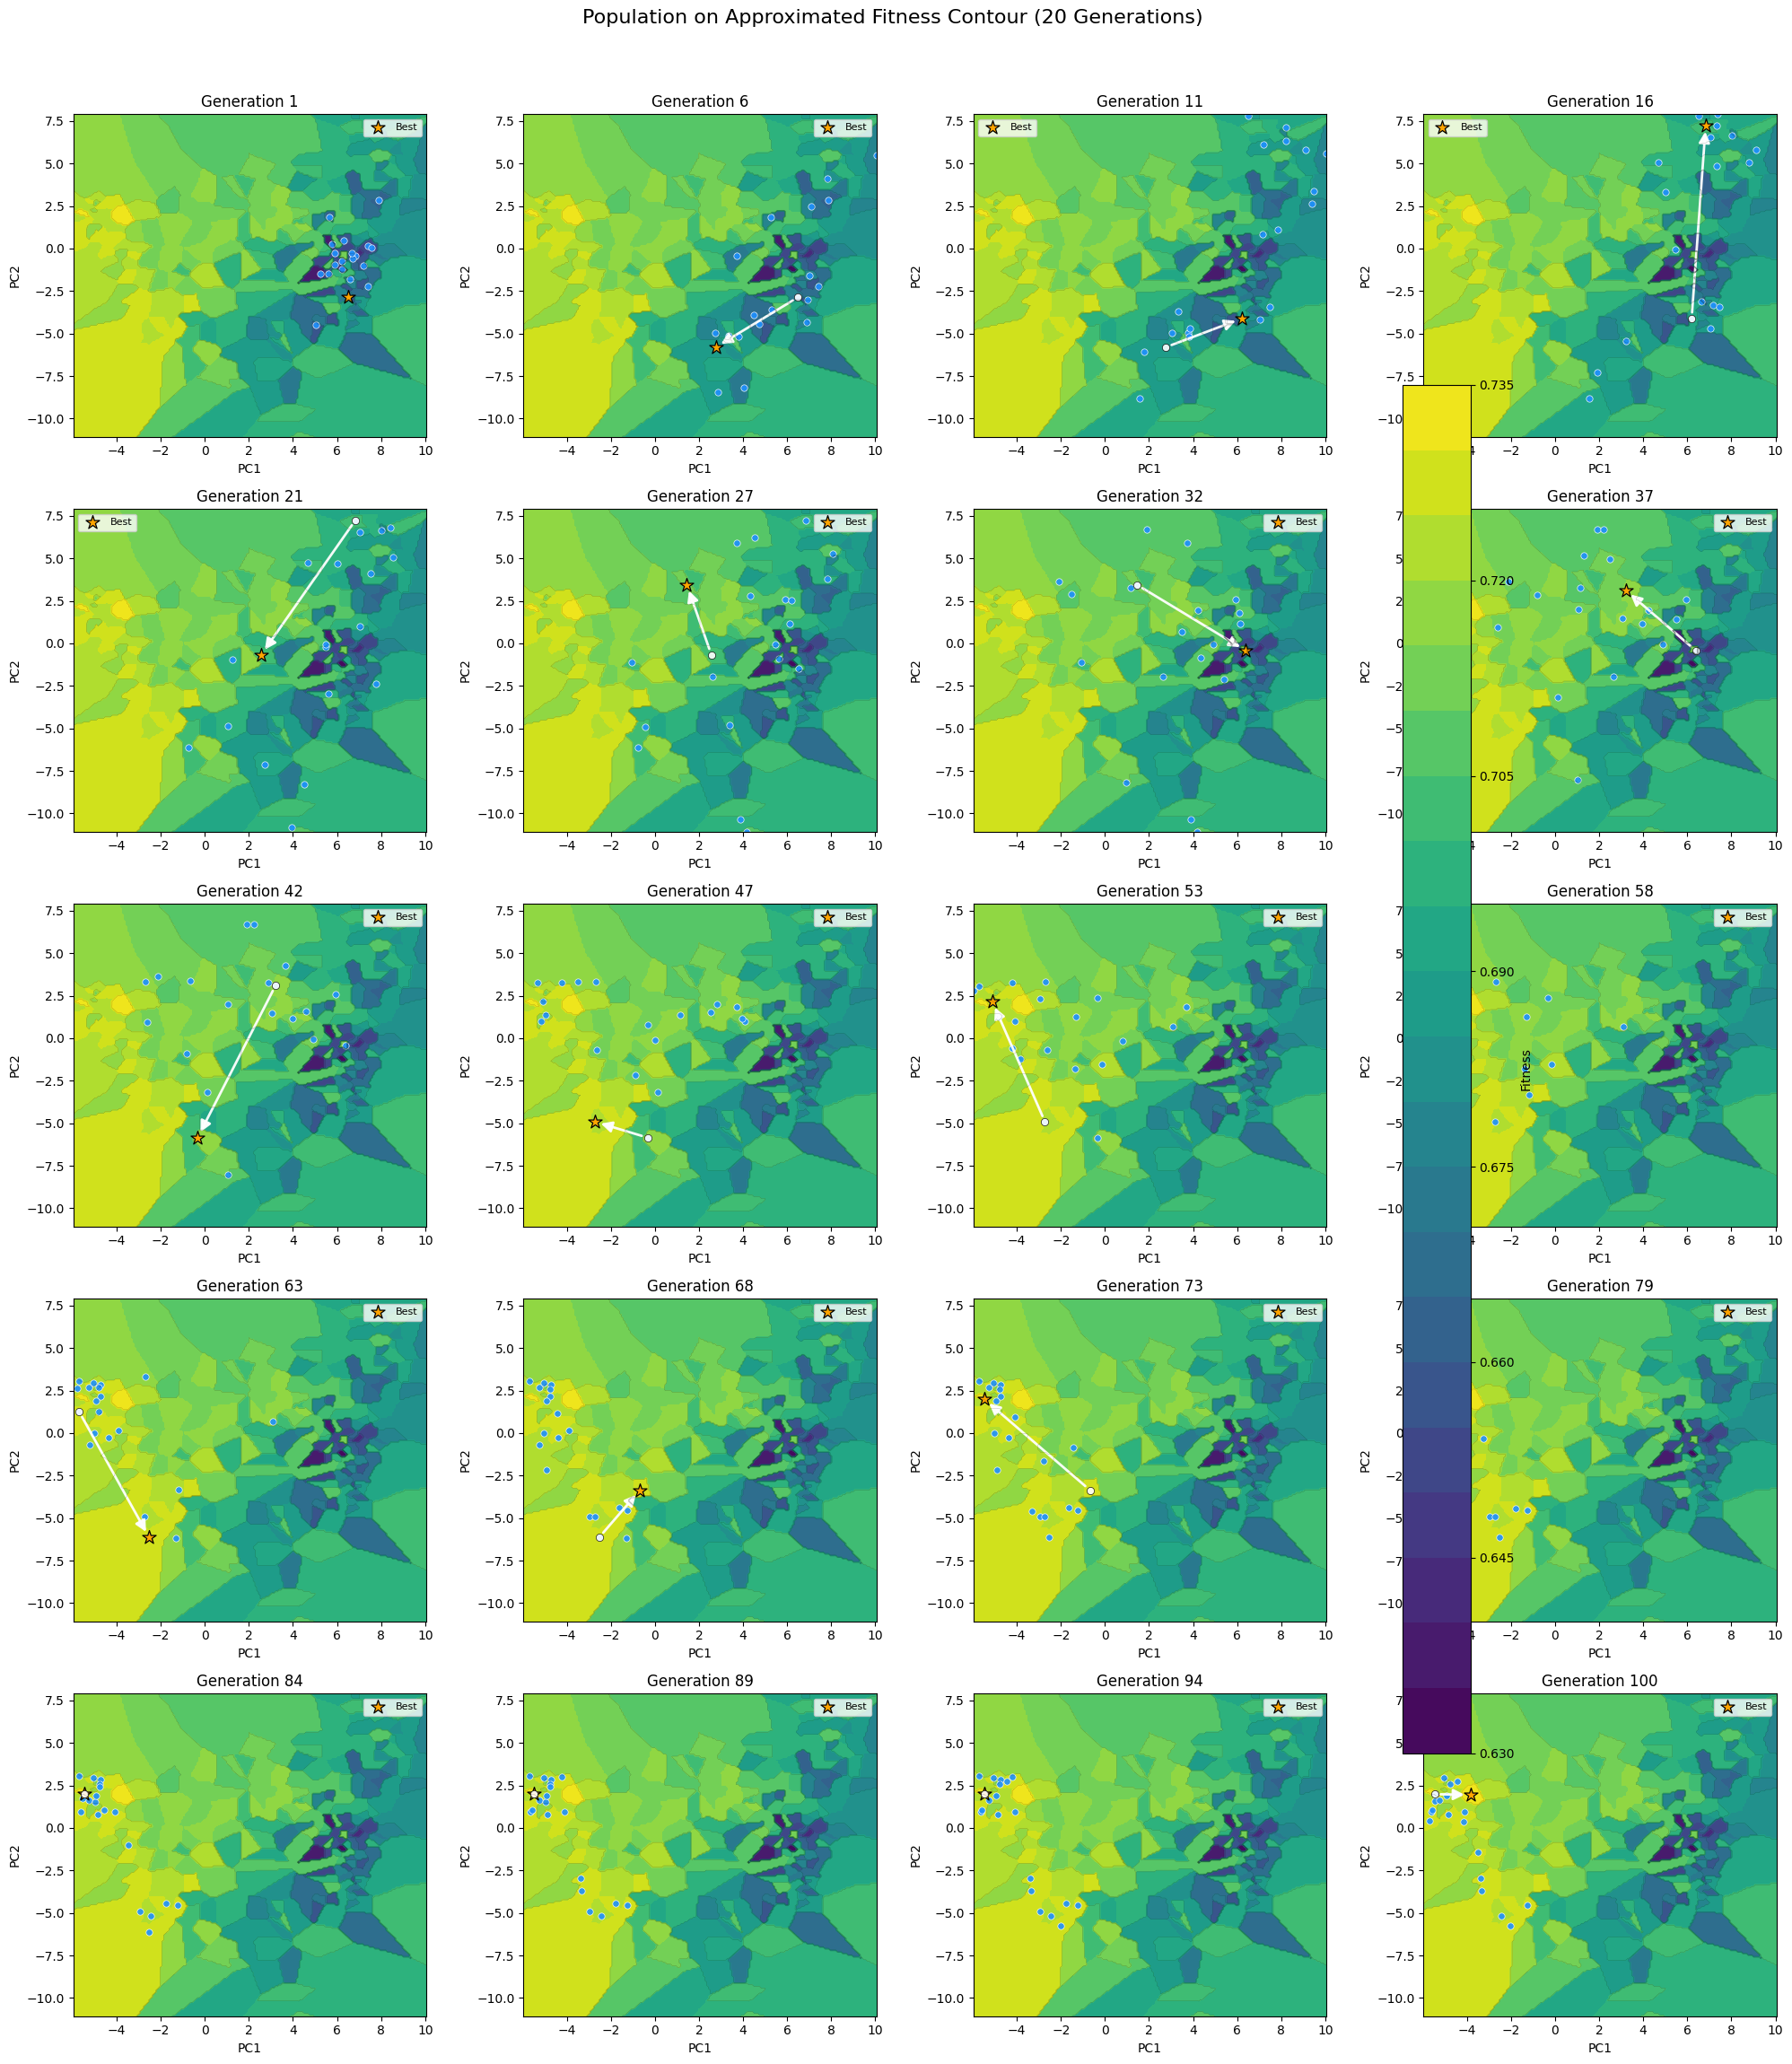

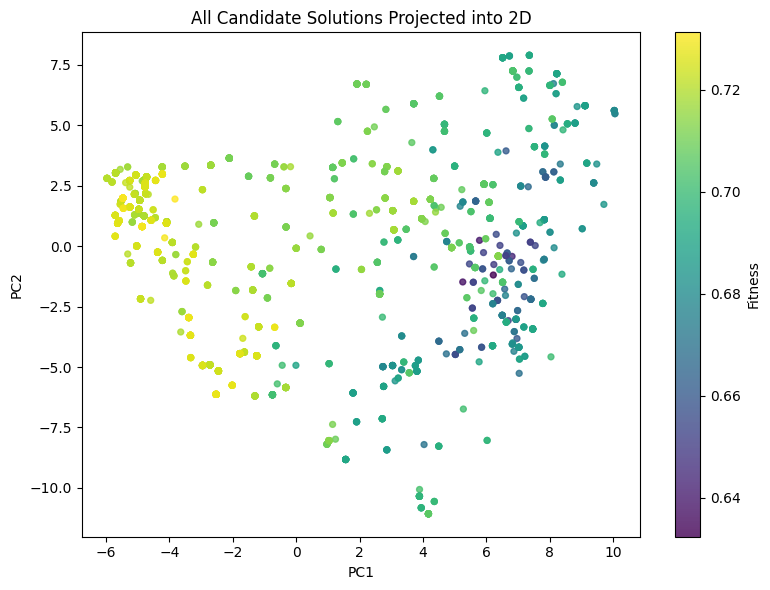

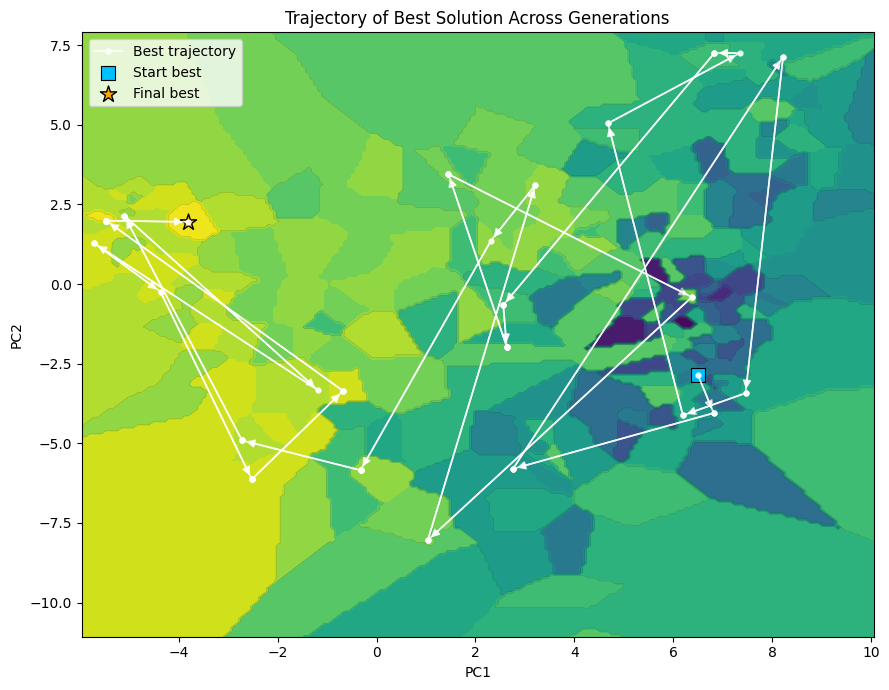

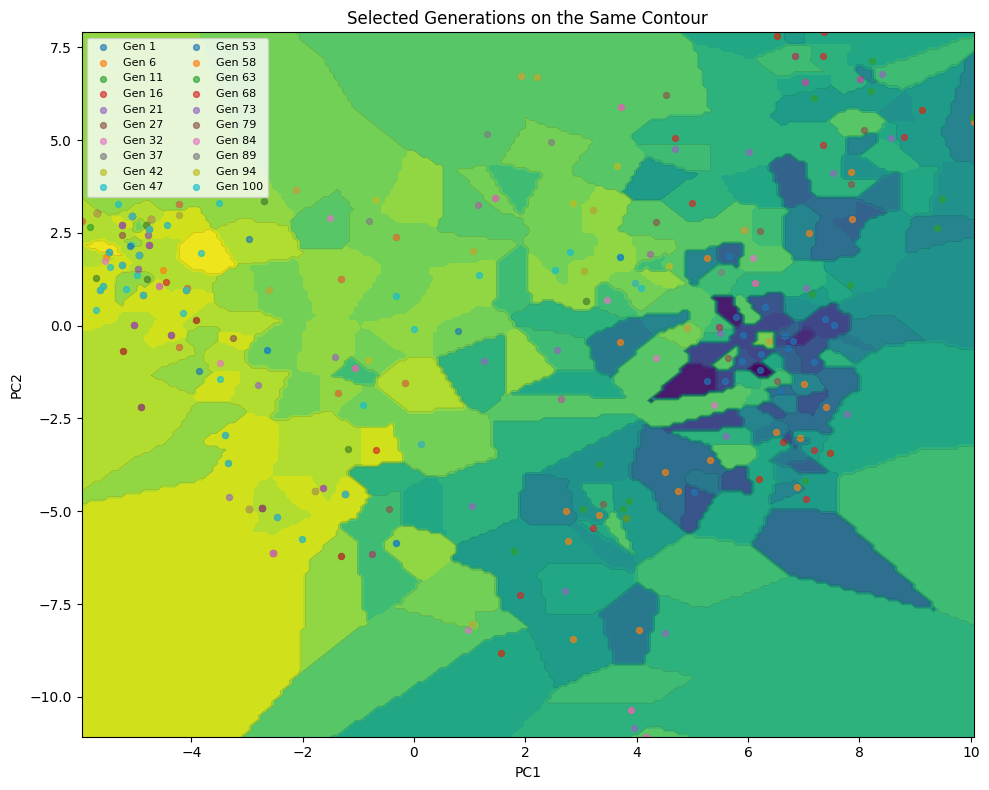

In [ ]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from matplotlib.patches import FancyArrowPatch


# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
csv_path = "/content/population_state_history.csv"
df = pd.read_csv(csv_path)

# Chuyển cột mask từ string -> list
df["mask"] = df["mask"].apply(ast.literal_eval)

# Dùng mask để trực quan hóa đúng bản chất feature selection
X_mask = np.array(df["mask"].tolist(), dtype=float)

fitness = df["fitness"].values
generations = df["generation"].values
individuals = df["individual"].values


# =========================
# 2. GIẢM CHIỀU XUỐNG 2D BẰNG PCA
# =========================
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_mask)

df["u"] = coords_2d[:, 0]
df["v"] = coords_2d[:, 1]


# =========================
# 3. TẠO CONTOUR XẤP XỈ FITNESS LANDSCAPE
# =========================
u = df["u"].values
v = df["v"].values
f = df["fitness"].values

grid_u, grid_v = np.meshgrid(
    np.linspace(u.min(), u.max(), 200),
    np.linspace(v.min(), v.max(), 200)
)

grid_f = griddata(
    points=(u, v),
    values=f,
    xi=(grid_u, grid_v),
    method="nearest"
)

if np.isnan(grid_f).any():
    grid_f_nearest = griddata(
        points=(u, v),
        values=f,
        xi=(grid_u, grid_v),
        method="nearest"
    )
    nan_mask = np.isnan(grid_f)
    grid_f[nan_mask] = grid_f_nearest[nan_mask]


# =========================
# 4. CHỌN 20 GENERATION TIÊU BIỂU
# =========================
all_gens = sorted(df["generation"].unique())

n_show = min(20, len(all_gens))

if len(all_gens) <= n_show:
    selected_gens = all_gens
else:
    idx = np.linspace(0, len(all_gens) - 1, n_show, dtype=int)
    selected_gens = sorted(list(dict.fromkeys([all_gens[i] for i in idx])))

print("Selected generations:", selected_gens)


# =========================
# 5. BEST CỦA MỖI GENERATION
# =========================
best_per_gen = df.loc[df.groupby("generation")["fitness"].idxmax()].sort_values("generation")
best_per_gen = best_per_gen.set_index("generation")


# =========================
# 6. VẼ 20 HÌNH: MỖI HÌNH 1 MŨI TÊN
# =========================
n_plots = len(selected_gens)
n_cols = 4
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)
axes = axes.flatten()

contour_ref = None

for plot_idx, gen in enumerate(selected_gens):
    ax = axes[plot_idx]
    sub = df[df["generation"] == gen].copy()

    # contour nền
    contour_ref = ax.contourf(grid_u, grid_v, grid_f, levels=20, cmap="viridis")
    ax.contour(grid_u, grid_v, grid_f, levels=10, colors="black", linewidths=0.25, alpha=0.35)

    # scatter quần thể generation hiện tại
    ax.scatter(
        sub["u"], sub["v"],
        s=28,
        c="dodgerblue",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.9
    )

    # best hiện tại
    best_row = best_per_gen.loc[gen]
    ax.scatter(
        best_row["u"], best_row["v"],
        s=130,
        marker="*",
        c="orange",
        edgecolors="black",
        linewidths=0.9,
        label="Best"
    )

    # ===== MỖI HÌNH 1 MŨI TÊN: từ best gen trước -> best gen hiện tại =====
    prev_candidates = [g for g in selected_gens[:plot_idx] if g < gen]
    if len(prev_candidates) > 0:
        prev_gen = prev_candidates[-1]
        prev_row = best_per_gen.loc[prev_gen]

        arrow = FancyArrowPatch(
            (prev_row["u"], prev_row["v"]),
            (best_row["u"], best_row["v"]),
            arrowstyle='-|>',
            mutation_scale=18,
            linewidth=2.0,
            color='white',
            alpha=0.95,
            shrinkA=5,
            shrinkB=5
        )
        ax.add_patch(arrow)

        # đánh dấu điểm bắt đầu mũi tên
        ax.scatter(
            prev_row["u"], prev_row["v"],
            s=35,
            c="white",
            edgecolors="black",
            linewidths=0.5,
            alpha=0.9
        )

    ax.set_title(f"Generation {gen}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best", fontsize=8)

# Ẩn các ô thừa nếu số hình < số subplot
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

fig.colorbar(contour_ref, ax=axes.tolist(), shrink=0.88, label="Fitness")
plt.suptitle("Population on Approximated Fitness Contour (20 Generations)", y=1.02, fontsize=16)
plt.tight_layout()

plt.savefig("population_contour_20_generations_with_arrows.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 7. VẼ TOÀN BỘ ĐIỂM THEO FITNESS
# =========================
plt.figure(figsize=(8, 6))
sc = plt.scatter(df["u"], df["v"], c=df["fitness"], s=18, alpha=0.8, cmap="viridis")
plt.colorbar(sc, label="Fitness")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("All Candidate Solutions Projected into 2D")
plt.tight_layout()
plt.savefig("all_population_projected_2d.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 8. VẼ TRAJECTORY CỦA BEST SOLUTION QUA CÁC GENERATION
# =========================
best_per_gen_reset = best_per_gen.reset_index()

plt.figure(figsize=(9, 7))
plt.contourf(grid_u, grid_v, grid_f, levels=20, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=10, colors="black", linewidths=0.25, alpha=0.35)

u_vals = best_per_gen_reset["u"].values
v_vals = best_per_gen_reset["v"].values
gen_vals = best_per_gen_reset["generation"].values

plt.plot(
    u_vals, v_vals,
    marker="o", linewidth=1.2, markersize=3.5,
    color="white", alpha=0.85,
    label="Best trajectory"
)

for i in range(len(u_vals) - 1):
    arrow = FancyArrowPatch(
        (u_vals[i], v_vals[i]),
        (u_vals[i + 1], v_vals[i + 1]),
        arrowstyle='-|>',
        mutation_scale=12,
        linewidth=1.2,
        color='white',
        alpha=0.85,
        shrinkA=3,
        shrinkB=3
    )
    plt.gca().add_patch(arrow)

first_row = best_per_gen_reset.iloc[0]
last_row = best_per_gen_reset.iloc[-1]

plt.scatter(first_row["u"], first_row["v"], s=100, marker="s", c="deepskyblue", edgecolors="black", linewidths=0.8, label="Start best")
plt.scatter(last_row["u"], last_row["v"], s=150, marker="*", c="orange", edgecolors="black", linewidths=1.0, label="Final best")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trajectory of Best Solution Across Generations")
plt.legend()
plt.tight_layout()
plt.savefig("best_solution_trajectory_with_arrows.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 9. VẼ CÁC GENERATION ĐƯỢC CHỌN TRÊN CÙNG 1 HÌNH
# =========================
plt.figure(figsize=(10, 8))
plt.contourf(grid_u, grid_v, grid_f, levels=20, cmap="viridis")
plt.contour(grid_u, grid_v, grid_f, levels=10, colors="black", linewidths=0.25, alpha=0.35)

for gen in selected_gens:
    sub = df[df["generation"] == gen]
    plt.scatter(sub["u"], sub["v"], s=18, alpha=0.65, label=f"Gen {gen}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Selected Generations on the Same Contour")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("selected_20_generations_same_contour.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.decomposition import PCA
from scipy.interpolate import griddata


# =========================
# CONFIG
# =========================
CSV_PATH = "population_state_history.csv"   # đổi nếu cần
OUT_DIR = Path("generation_frames")
GRID_SIZE = 200
CONTOUR_LEVELS = 20
CMAP = "viridis"


# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
df = pd.read_csv(CSV_PATH)

required_cols = {"generation", "individual", "fitness", "mask"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV thiếu các cột bắt buộc: {missing}")

# mask từ string -> list
df["mask"] = df["mask"].apply(ast.literal_eval)

# dùng mask để phản ánh đúng feature subset
X_mask = np.array(df["mask"].tolist(), dtype=float)


# =========================
# 2. PCA XUỐNG 2D
# =========================
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_mask)

df["u"] = coords_2d[:, 0]
df["v"] = coords_2d[:, 1]


# =========================
# 3. DỰNG CONTOUR FITNESS
# =========================
u = df["u"].values
v = df["v"].values
f = df["fitness"].values

grid_u, grid_v = np.meshgrid(
    np.linspace(u.min(), u.max(), GRID_SIZE),
    np.linspace(v.min(), v.max(), GRID_SIZE)
)

# nearest để tránh "đỉnh giả"
grid_f = griddata(
    points=(u, v),
    values=f,
    xi=(grid_u, grid_v),
    method="nearest"
)

if np.isnan(grid_f).any():
    grid_f_nearest = griddata(
        points=(u, v),
        values=f,
        xi=(grid_u, grid_v),
        method="nearest"
    )
    nan_mask = np.isnan(grid_f)
    grid_f[nan_mask] = grid_f_nearest[nan_mask]


# =========================
# 4. BEST CỦA MỖI GENERATION
# =========================
best_per_gen = df.loc[df.groupby("generation")["fitness"].idxmax()].sort_values("generation")
best_per_gen = best_per_gen.set_index("generation")

all_gens = sorted(df["generation"].unique())


# =========================
# 5. HÀM VẼ 1 GENERATION
# =========================
def save_one_generation_frame(gen: int, out_path: Path):
    sub = df[df["generation"] == gen].copy()
    best_row = best_per_gen.loc[gen]

    fig, ax = plt.subplots(figsize=(8, 6))

    contour = ax.contourf(grid_u, grid_v, grid_f, levels=CONTOUR_LEVELS, cmap=CMAP)
    ax.contour(
        grid_u, grid_v, grid_f,
        levels=max(6, CONTOUR_LEVELS // 2),
        colors="black",
        linewidths=0.25,
        alpha=0.35
    )

    # quần thể của generation hiện tại
    ax.scatter(
        sub["u"], sub["v"],
        s=32,
        c="dodgerblue",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.92,
        label="Population"
    )

    # best hiện tại
    ax.scatter(
        best_row["u"], best_row["v"],
        s=170,
        marker="*",
        c="orange",
        edgecolors="black",
        linewidths=0.9,
        zorder=5,
        label="Best"
    )

    # mũi tên từ best gen trước -> best gen hiện tại
    gen_position = all_gens.index(gen)
    if gen_position > 0:
        prev_gen = all_gens[gen_position - 1]
        prev_row = best_per_gen.loc[prev_gen]

        # điểm bắt đầu mũi tên
        ax.scatter(
            prev_row["u"], prev_row["v"],
            s=42,
            c="white",
            edgecolors="black",
            linewidths=0.5,
            alpha=0.95,
            zorder=4
        )

        arrow = FancyArrowPatch(
            (prev_row["u"], prev_row["v"]),
            (best_row["u"], best_row["v"]),
            arrowstyle='-|>',
            mutation_scale=20,
            linewidth=2.0,
            color='white',
            alpha=0.97,
            shrinkA=6,
            shrinkB=6
        )
        ax.add_patch(arrow)

    ax.set_title(f"Generation {gen}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

    fig.colorbar(contour, ax=ax, shrink=0.9, label="Fitness")
    plt.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


# =========================
# 6. LƯU TỪNG GENERATION THÀNH 1 ẢNH
# =========================
OUT_DIR.mkdir(parents=True, exist_ok=True)

for gen in all_gens:
    out_file = OUT_DIR / f"generation_{int(gen):03d}.png"
    save_one_generation_frame(gen, out_file)

print(f"Đã lưu {len(all_gens)} ảnh vào thư mục: {OUT_DIR.resolve()}")

Đã lưu 100 ảnh vào thư mục: /content/generation_frames


In [ ]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.decomposition import PCA
from scipy.interpolate import griddata


# =========================
# CONFIG
# =========================
CSV_PATH = "population_state_history.csv"   # đổi nếu cần
OUT_DIR = Path("generation_frames")
GRID_SIZE = 200
CONTOUR_LEVELS = 20
CMAP = "viridis"


# =========================
# 1. ĐỌC DỮ LIỆU
# =========================
df = pd.read_csv(CSV_PATH)

required_cols = {"generation", "individual", "fitness", "mask"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV thiếu các cột bắt buộc: {missing}")

df["mask"] = df["mask"].apply(ast.literal_eval)
X_mask = np.array(df["mask"].tolist(), dtype=float)


# =========================
# 2. PCA XUỐNG 2D
# =========================
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_mask)

df["u"] = coords_2d[:, 0]
df["v"] = coords_2d[:, 1]


# =========================
# 3. DỰNG CONTOUR FITNESS
# =========================
u = df["u"].values
v = df["v"].values
f = df["fitness"].values

grid_u, grid_v = np.meshgrid(
    np.linspace(u.min(), u.max(), GRID_SIZE),
    np.linspace(v.min(), v.max(), GRID_SIZE)
)

grid_f = griddata(
    points=(u, v),
    values=f,
    xi=(grid_u, grid_v),
    method="nearest"
)

if np.isnan(grid_f).any():
    grid_f_nearest = griddata(
        points=(u, v),
        values=f,
        xi=(grid_u, grid_v),
        method="nearest"
    )
    nan_mask = np.isnan(grid_f)
    grid_f[nan_mask] = grid_f_nearest[nan_mask]


# =========================
# 4. BEST CỦA MỖI GENERATION
# =========================
best_per_gen = df.loc[df.groupby("generation")["fitness"].idxmax()].sort_values("generation")
best_per_gen = best_per_gen.set_index("generation")

all_gens = sorted(df["generation"].unique())


# =========================
# 5. HÀM VẼ 1 GENERATION
# =========================
def save_one_generation_frame(gen: int, out_path: Path):
    sub = df[df["generation"] == gen].copy()
    best_row = best_per_gen.loc[gen]

    fig, ax = plt.subplots(figsize=(8, 6))

    contour = ax.contourf(grid_u, grid_v, grid_f, levels=CONTOUR_LEVELS, cmap=CMAP)
    ax.contour(
        grid_u, grid_v, grid_f,
        levels=max(6, CONTOUR_LEVELS // 2),
        colors="black",
        linewidths=0.25,
        alpha=0.35
    )

    # quần thể của generation hiện tại
    ax.scatter(
        sub["u"], sub["v"],
        s=32,
        c="dodgerblue",
        edgecolors="white",
        linewidths=0.5,
        alpha=0.92,
        label="Population"
    )

    # best hiện tại
    ax.scatter(
        best_row["u"], best_row["v"],
        s=170,
        marker="*",
        c="orange",
        edgecolors="black",
        linewidths=0.9,
        zorder=5,
        label="Best current"
    )

    # ===== mũi tên từ best gen hiện tại -> best gen sau =====
    gen_position = all_gens.index(gen)
    if gen_position < len(all_gens) - 1:
        next_gen = all_gens[gen_position + 1]
        next_row = best_per_gen.loc[next_gen]

        # đánh dấu best của gen sau
        ax.scatter(
            next_row["u"], next_row["v"],
            s=52,
            c="white",
            edgecolors="black",
            linewidths=0.6,
            alpha=0.95,
            zorder=4,
            label="Best next"
        )

        arrow = FancyArrowPatch(
            (best_row["u"], best_row["v"]),
            (next_row["u"], next_row["v"]),
            arrowstyle='-|>',
            mutation_scale=20,
            linewidth=2.0,
            color='white',
            alpha=0.97,
            shrinkA=6,
            shrinkB=6
        )
        ax.add_patch(arrow)

    ax.set_title(f"Generation {gen}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(loc="best")

    fig.colorbar(contour, ax=ax, shrink=0.9, label="Fitness")
    plt.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


# =========================
# 6. LƯU TỪNG GENERATION THÀNH 1 ẢNH
# =========================
OUT_DIR.mkdir(parents=True, exist_ok=True)

for gen in all_gens:
    out_file = OUT_DIR / f"generation_{int(gen):03d}.png"
    save_one_generation_frame(gen, out_file)

print(f"Đã lưu {len(all_gens)} ảnh vào thư mục: {OUT_DIR.resolve()}")

Đã lưu 100 ảnh vào thư mục: /content/generation_frames


In [ ]:
zip_path = 'generation_frames.zip'

In [ ]:
import shutil

shutil.make_archive(zip_path.replace('.zip', ''), 'zip', OUT_DIR)
print(f"Đã tạo file zip tại: {zip_path}")

Đã tạo file zip tại: generation_frames.zip


In [ ]:
from google.colab import files
files.download('generation_frames.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>